## 读取数据（原始数据，未经过log变换），共18个样品，每个样品有数个测片。以下代码选取了样品601（2）与602（2）作为物源。各使用两个指数函数（分别代表快慢组分）进行拟合

## 此处我首先计算601（2）和602（2）中的快慢组分：

### 1&nbsp;. Mean decade curve  

$$
\overline{I}_X(t)
= \frac{1}{N}\,\sum_{i=1}^{N} I_{X,i}(t)
$$  

Here \(I_{X,i}(t)\) is the raw OSL count rate of slice \(i\) for sample \(X\) at time \(t\).

---

### 2&nbsp;. Two‑component exponential model  

$$
I(t)\;=\;A_{1}\,e^{-k_{1}t} \;+\; A_{2}\,e^{-k_{2}t}
$$  

* \(A_{1},k_{1}\) — amplitude and decay constant of the **fast** component  
* \(A_{2},k_{2}\) — amplitude and decay constant of the **slow** component  

For source 602 an independent set \((B_{1},k_{1}',B_{2},k_{2}')\) is fitted.

---

### 3&nbsp;. Goodness‑of‑fit (\(R^{2}\))  

$$
R^{2}
= 1 -
\frac{\displaystyle\sum_{t}
       \bigl[\,I_{\text{data}}(t) - I_{\text{fit}}(t)\bigr]^{2}}
     {\displaystyle\sum_{t}
       \bigl[\,I_{\text{data}}(t) - \overline{I_{\text{data}}}\,\bigr]^{2}}
$$


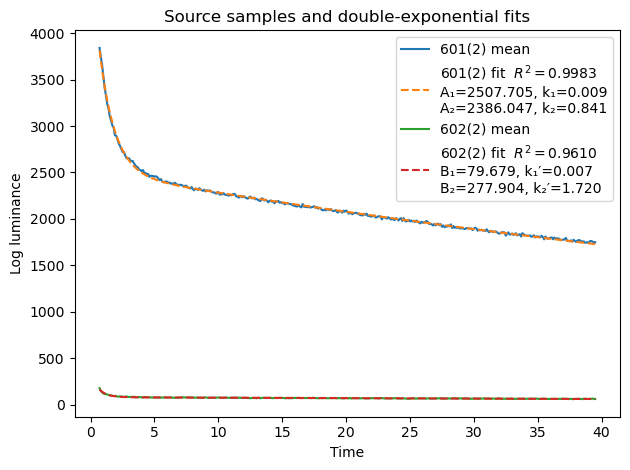

A1: 2507.705, A2: 2386.047, B1: 79.679, B2: 277.904 r2_601 0.998
k1: 0.009, k2: 0.841, k1b: 0.007, k2b: 1.720 r2_602 0.961


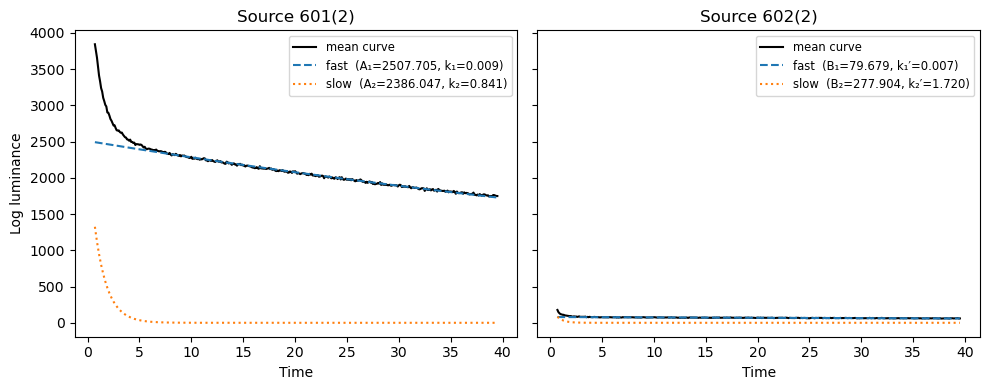

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------- Helper utilities --------------------
def load_data(path="output/processed_new_data_ori.pkl"):
    """Load the pickled dictionary that contains all sample dataframes."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Pickle file not found at '{path}'. Please make sure the path is correct."
        )
    with open(path, "rb") as f:
        return pickle.load(f)


def mean_curve(df, key):
    """
    Return time vector and the mean of all slice columns for a given dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe corresponding to one sample.
    key : str
        The sample key, e.g. '601(2)' or '511'.  The part before a '(' (if any)
        is used to match slice‑column names, e.g. 'Sample_601'.
    """
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [c for c in df.columns if c.startswith(prefix)]
    t = df["Time"].values.astype(float)
    y = df[slice_cols].mean(axis=1).values.astype(float)
    return t, y


def double_exp(t, A1, k1, A2, k2):
    """Two‑term exponential decay."""
    return A1 * np.exp(-k1 * t) + A2 * np.exp(-k2 * t)


def r2_score(y_true, y_pred):
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    sse = np.sum((y_true - y_pred) ** 2)
    return 1.0 - sse / sst


# -------------------- STEP 1: fit the two “source” samples --------------------
data_dict = load_data()

# Fit sample 601(2)
t_601, y_601 = mean_curve(data_dict["601(2)"], "601(2)")
p0_601 = [1.0, 0.05, 0.5, 0.005]  # rough starting guesses
A1, k1, A2, k2 = curve_fit(double_exp, t_601, y_601, p0=p0_601, maxfev=10000)[0]
fit_601 = double_exp(t_601, A1, k1, A2, k2)
r2_601 = r2_score(y_601, fit_601)

# Fit sample 602(2)
t_602, y_602 = mean_curve(data_dict["602(2)"], "602(2)")
p0_602 = [A1, k1, A2, k2]  # use previous fit as a reasonable initial guess
B1, k1b, B2, k2b = curve_fit(double_exp, t_602, y_602, p0=p0_602, maxfev=10000)[0]
fit_602 = double_exp(t_602, B1, k1b, B2, k2b)
r2_602 = r2_score(y_602, fit_602)

# Plot the two means and their double‑exponential fits
plt.figure()
plt.plot(t_601, y_601, label="601(2) mean")
plt.plot(
    t_601,
    fit_601,
    "--",
    label=(
        f"601(2) fit  $R^2={r2_601:.4f}$\n"
        f"A₁={A1:.3f}, k₁={k1:.3f}\nA₂={A2:.3f}, k₂={k2:.3f}"
    ),
)
plt.plot(t_602, y_602, label="602(2) mean")
plt.plot(
    t_602,
    fit_602,
    "--",
    label=(
        f"602(2) fit  $R^2={r2_602:.4f}$\n"
        f"B₁={B1:.3f}, k₁′={k1b:.3f}\nB₂={B2:.3f}, k₂′={k2b:.3f}"
    ),
)
plt.xlabel("Time")
plt.ylabel("Log luminance")
plt.title("Source samples and double‑exponential fits")
plt.legend()
plt.tight_layout()
plt.show()


# print A1, A2, B1, B2 AND k1, k2, k1b, k2b
print(f"A1: {A1:.3f}, A2: {A2:.3f}, B1: {B1:.3f}, B2: {B2:.3f}",'r2_601', f"{r2_601:.3f}")
print(f"k1: {k1:.3f}, k2: {k2:.3f}, k1b: {k1b:.3f}, k2b: {k2b:.3f}", 'r2_602', f"{r2_602:.3f}")



# ------------------------------------------------------------
#  Figure: 601(2) vs 602(2) – mean, fast term, slow term
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---------- 601(2) ----------
fast_601 = A1 * np.exp(-k1 * t_601)
slow_601 = A2 * np.exp(-k2 * t_601)

ax[0].plot(t_601, y_601,  color="k", label="mean curve")
ax[0].plot(t_601, fast_601, "--", label=f"fast  (A₁={A1:.3f}, k₁={k1:.3f})")
ax[0].plot(t_601, slow_601, ":",  label=f"slow  (A₂={A2:.3f}, k₂={k2:.3f})")
ax[0].set_title("Source 601(2)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Log luminance")
ax[0].legend(fontsize="small")

# ---------- 602(2) ----------
fast_602 = B1 * np.exp(-k1b * t_602)
slow_602 = B2 * np.exp(-k2b * t_602)

ax[1].plot(t_602, y_602,  color="k", label="mean curve")
ax[1].plot(t_602, fast_602, "--", label=f"fast  (B₁={B1:.3f}, k₁′={k1b:.3f})")
ax[1].plot(t_602, slow_602, ":",  label=f"slow  (B₂={B2:.3f}, k₂′={k2b:.3f})")
ax[1].set_title("Source 602(2)")
ax[1].set_xlabel("Time")
ax[1].legend(fontsize="small")

plt.tight_layout()
plt.show()


# 接下来我计算了混合比：

假设每个样品中都包含了来自601（2）和602（2）的快慢组分。保持k1, k2, k1b, k2b不变。为每个样品的均值曲线拟合出合适的A1', A2', B1', B2'

根据 A1', A2', B1', B2' 可以计算出混合比为：

Let  

\[
\begin{aligned}
S_{601}&=A_1'+A_2'\\[4pt]
S_{602}&=B_1'+B_2'\\[4pt]
S_{\text{tot}}&=S_{601}+S_{602}
\end{aligned}
\qquad\Longrightarrow\qquad
\begin{aligned}
\text{Fraction from 601(2)} &= \dfrac{S_{601}}{S_\text{tot}}\\[8pt]
\text{Fraction from 602(2)} &= \dfrac{S_{602}}{S_\text{tot}}
\end{aligned}
\tag{5}
\]

---

### Parameter symbols used in the code

| Symbol | Code variable | Description |
|:------:|---------------|-------------|
| \(A_1 ,k_1 ,A_2 ,k_2\) | `A1, k1, A2, k2` | Fit to source 601(2) |
| \(B_1 ,k_1',B_2 ,k_2'\) | `B1, k1b, B2, k2b` | Fit to source 602(2) |
| \(A_1',A_2',B_1',B_2'\) | `amps` from NNLS | Sample‑specific amplitudes in Eq. (4) |
| \(R^2\) | `r2_score` | Fit quality defined in Eq. (3) |


In [5]:
# ------------------------------------------------------------
#  STEP 3  –  four‑component fit for every sample
#             (A1′,A2′ from 601 rates; B1′,B2′ from 602 rates)
# ------------------------------------------------------------
def basis_matrix4(t):
    """exp(-k1 t), exp(-k2 t), exp(-k1b t), exp(-k2b t) columns."""
    return np.column_stack(
        (np.exp(-k1 * t), np.exp(-k2 * t),
         np.exp(-k1b* t), np.exp(-k2b* t))
    )

records = []
for key, df in data_dict.items():
    t, y   = mean_curve(df, key)
    X4     = basis_matrix4(t)
    a1p, a2p, b1p, b2p, *_ = np.linalg.lstsq(X4, y, rcond=None)[0]
    yhat   = X4 @ np.array([a1p, a2p, b1p, b2p])
    r2val  = r2_score(y, yhat)

    fast_sum  = a1p + b1p
    all_sum   = a1p + a2p + b1p + b2p
    mix_fast  = a1p / fast_sum if fast_sum else np.nan
    mix_all   = (a1p + a2p) / all_sum if all_sum else np.nan

    records.append([key, a1p, a2p, b1p, b2p, r2val, mix_fast, mix_all])

# ------------------------------------------------------------
#  Result table
# ------------------------------------------------------------
cols = ["A1′(fast601)", "A2′(slow601)",
        "B1′(fast602)", "B2′(slow602)",
        "R²", "Mix601 (fast)", "Mix601 (all)"]

df_coef = (pd.DataFrame.from_records(records, columns=["Sample", *cols])
                     .set_index("Sample")
                     .round(4)
                     .sort_index())

print("\n=== Four‑exp amplitudes & mixing ratios ===")
print(df_coef.to_string())

# Optional CSV
df_coef.to_csv("output/four_exp_coefficients_and_mixing.csv")
print("\nSaved → four_exp_coefficients_and_mixing.csv")

# If running in Jupyter, show nicely
try:
    from IPython.display import display
    display(df_coef)
except Exception:
    pass


# ------------------------------------------------------------
#  STEP 4 – total‑signal mixing fractions of every sample
#            (includes both fast and slow components)
# ------------------------------------------------------------
# df_coef already contains A1′, A2′, B1′, B2′ for every sample

df_coef["Total_601"] = df_coef["A1′(fast601)"] + df_coef["A2′(slow601)"]
df_coef["Total_602"] = df_coef["B1′(fast602)"] + df_coef["B2′(slow602)"]
df_coef["Total_sum"] = df_coef["Total_601"] + df_coef["Total_602"]

df_coef["Frac601_total"] = df_coef["Total_601"] / df_coef["Total_sum"]
df_coef["Frac602_total"] = df_coef["Total_602"] / df_coef["Total_sum"]

# neat ordering
out_cols = ["A1′(fast601)", "A2′(slow601)",
            "B1′(fast602)", "B2′(slow602)",
            "R²", "Frac601_total", "Frac602_total"]

df_mix = df_coef[out_cols].round(4)

print("\n=== Total‑signal mixing fractions ===")
print(df_mix.to_string())

df_mix.to_csv("output/total_signal_mixing_fractions.csv")
print("\nSaved → total_signal_mixing_fractions.csv")

# Jupyter display
try:
    from IPython.display import display
    display(df_mix)
except Exception:
    pass



=== Four‑exp amplitudes & mixing ratios ===
        A1′(fast601)  A2′(slow601)  B1′(fast602)  B2′(slow602)      R²  Mix601 (fast)  Mix601 (all)
Sample                                                                                             
511         213.9680       50.1623     -156.6419      454.7931  0.9599         3.7325        0.4697
512         144.5658      -30.6000     -105.6984      778.1612  0.9565         3.7195        0.1449
513         220.4255       40.4411     -170.7528      915.6825  0.9559         4.4376        0.2594
514         130.7142      -24.1191      -91.6144      840.8362  0.9545         3.3431        0.1246
515         146.0537       33.9146      -87.2950      554.5411  0.9634         2.4857        0.2781
516         311.7123       81.5826     -253.7651     1184.2917  0.9503         5.3793        0.2971
517         384.7099     -147.2182     -289.7620     2509.6057  0.9470         4.0518        0.0966
518         575.3192     -980.9059     -500.9363     68

,A1′(fast601),A2′(slow601),B1′(fast602),B2′(slow602),R²,Mix601 (fast),Mix601 (all)
Sample,,,,,,,
511,213.9680,50.1623,-156.6419,454.7931,0.9599,3.7325,0.4697
512,144.5658,-30.6000,-105.6984,778.1612,0.9565,3.7195,0.1449
513,220.4255,40.4411,-170.7528,915.6825,0.9559,4.4376,0.2594
514,130.7142,-24.1191,-91.6144,840.8362,0.9545,3.3431,0.1246
515,146.0537,33.9146,-87.2950,554.5411,0.9634,2.4857,0.2781
516,311.7123,81.5826,-253.7651,1184.2917,0.9503,5.3793,0.2971
517,384.7099,-147.2182,-289.7620,2509.6057,0.9470,4.0518,0.0966
518,575.3192,-980.9059,-500.9363,6894.5274,0.9478,7.7346,-0.0677
522(2),197.4594,-247.2010,-75.6358,2479.7560,0.9183,1.6209,-0.0211



=== Total‑signal mixing fractions ===
        A1′(fast601)  A2′(slow601)  B1′(fast602)  B2′(slow602)      R²  Frac601_total  Frac602_total
Sample                                                                                              
511         213.9680       50.1623     -156.6419      454.7931  0.9599         0.4697         0.5303
512         144.5658      -30.6000     -105.6984      778.1612  0.9565         0.1449         0.8551
513         220.4255       40.4411     -170.7528      915.6825  0.9559         0.2594         0.7406
514         130.7142      -24.1191      -91.6144      840.8362  0.9545         0.1246         0.8754
515         146.0537       33.9146      -87.2950      554.5411  0.9634         0.2781         0.7219
516         311.7123       81.5826     -253.7651     1184.2917  0.9503         0.2971         0.7029
517         384.7099     -147.2182     -289.7620     2509.6057  0.9470         0.0966         0.9034
518         575.3192     -980.9059     -500.9363    

,A1′(fast601),A2′(slow601),B1′(fast602),B2′(slow602),R²,Frac601_total,Frac602_total
Sample,,,,,,,
511,213.9680,50.1623,-156.6419,454.7931,0.9599,0.4697,0.5303
512,144.5658,-30.6000,-105.6984,778.1612,0.9565,0.1449,0.8551
513,220.4255,40.4411,-170.7528,915.6825,0.9559,0.2594,0.7406
514,130.7142,-24.1191,-91.6144,840.8362,0.9545,0.1246,0.8754
515,146.0537,33.9146,-87.2950,554.5411,0.9634,0.2781,0.7219
516,311.7123,81.5826,-253.7651,1184.2917,0.9503,0.2971,0.7029
517,384.7099,-147.2182,-289.7620,2509.6057,0.9470,0.0966,0.9034
518,575.3192,-980.9059,-500.9363,6894.5274,0.9478,-0.0677,1.0677
522(2),197.4594,-247.2010,-75.6358,2479.7560,0.9183,-0.0211,1.0211


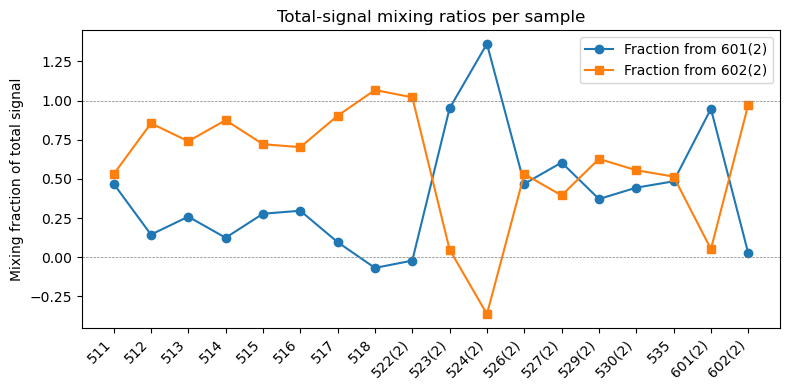

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


df_plot = df_mix.copy()

# Sort samples in alphabetical order for consistent x‑axis
df_plot = df_plot.sort_index()

x = range(len(df_plot))
plt.figure(figsize=(8, 4))
plt.plot(x, df_plot["Frac601_total"], marker="o", label="Fraction from 601(2)")
plt.plot(x, df_plot["Frac602_total"], marker="s", label="Fraction from 602(2)")
# plot horizontal lines at y=0 and 1
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(x, df_plot.index, rotation=45, ha="right")
plt.ylabel("Mixing fraction of total signal")
plt.title("Total‑signal mixing ratios per sample")
plt.legend()
plt.tight_layout()
plt.show()


## 结论：518， 522（2）和524（2）或不属于601（2）与602（2）的体系。

# 以下为每个测片的混合比

Decay rates used: (0.009432716318955968, 0.8411511954042122, 0.007172604869440638, 1.7201301163022527)


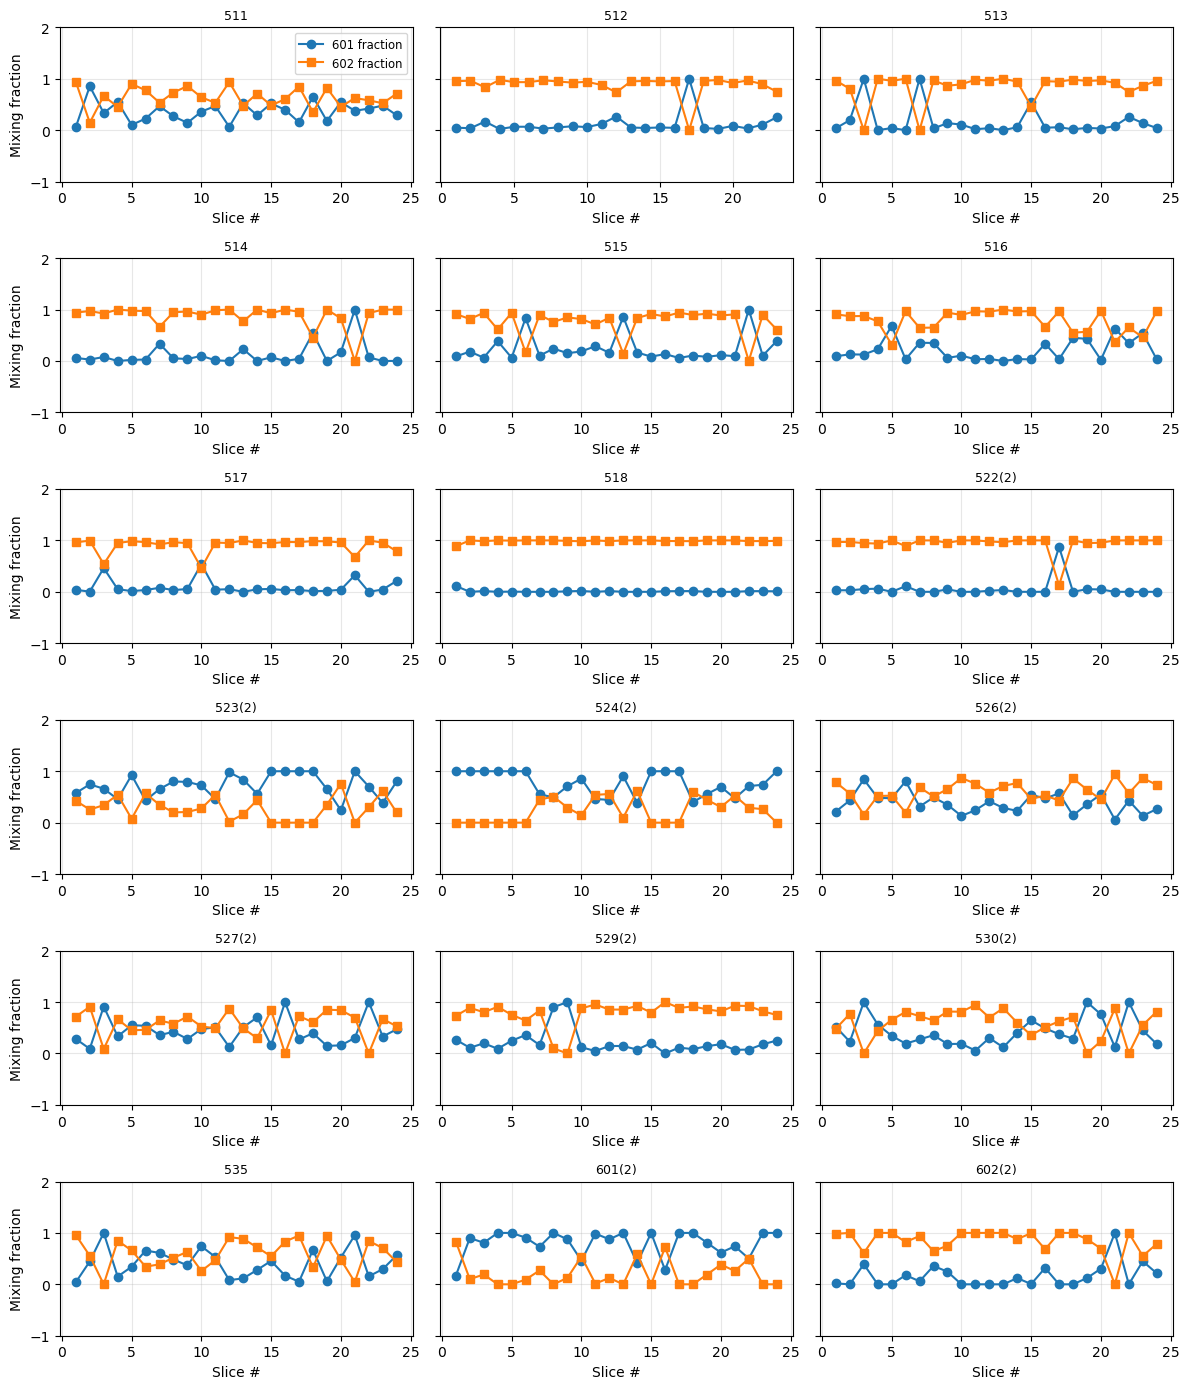

In [11]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls   # non‑negative least squares

# ------------------------------------------------------------------
# 1. Load the **raw‑count** pickle and reuse the fitted decay rates
#    (k1, k2 from 601; k1b, k2b from 602) already in memory.
# ------------------------------------------------------------------
data = load_data("output/processed_new_data_ori.pkl")   # uses your helper

# make sure k1, k2, k1b, k2b are defined from the source fits above
rates = (k1, k2, k1b, k2b)
print("Decay rates used:", rates)

# ------------------------------------------------------------------
# 2. Helper: four‑column design matrix with the fixed rates
# ------------------------------------------------------------------
def design_4exp(t, k1, k2, k1b, k2b):
    return np.column_stack([
        np.exp(-k1  * t),      # fast‑601   (A1′)
        np.exp(-k2  * t),      # slow‑601   (A2′)
        np.exp(-k1b * t),      # fast‑602   (B1′)
        np.exp(-k2b * t),      # slow‑602   (B2′)
    ])

# ------------------------------------------------------------------
# 3. For every sample & every slice: solve NNLS amplitudes,
#    then compute total‑signal fractions for 601 and 602.
# ------------------------------------------------------------------
mix_dict = {}   # sample -> list of (frac601, frac602) per slice

for key, df in data.items():
    t  = df["Time"].to_numpy(dtype=float)
    X  = design_4exp(t, *rates)
    
    prefix = f"Sample_{key.split('(')[0]}"
    slice_cols = [col for col in df.columns if col.startswith(prefix)]
    
    fracs_601, fracs_602 = [], []
    for col in slice_cols:
        y = df[col].to_numpy(dtype=float)
        # non‑negative least squares for A1′,A2′,B1′,B2′
        amps, _ = nnls(X, y)
        a1p, a2p, b1p, b2p = amps
        total601 = a1p + a2p
        total602 = b1p + b2p
        denom    = total601 + total602
        fracs_601.append(total601 / denom if denom else np.nan)
        fracs_602.append(total602 / denom if denom else np.nan)
    
    mix_dict[key] = (np.array(fracs_601), np.array(fracs_602))


samples_sorted = sorted(mix_dict.keys())
n_rows, n_cols = 6, 3                        # 6×3 = 18 panels
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(12, 14), sharey=True)
axes = axes.ravel()

for idx, (ax, sample) in enumerate(zip(axes, samples_sorted)):
    frac601, frac602 = mix_dict[sample]
    slices = np.arange(1, len(frac601) + 1)

    ax.plot(slices, frac601, "-o", label="601 fraction")
    ax.plot(slices, frac602, "-s", label="602 fraction")
    ax.set_title(sample, fontsize=9)
    ax.set_xlabel("Slice #")
    ax.set_ylim(-1, 2)
    ax.grid(True, alpha=0.3)

    # first column → add common y‑label
    if idx % n_cols == 0:
        ax.set_ylabel("Mixing fraction")

    # put the legend only on the very first subplot to avoid clutter
    if idx == 0:
        ax.legend(fontsize="small", loc="upper right")

# Hide any leftover empty axes (if <18 samples)
for ax in axes[len(samples_sorted):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
